In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib

# Set Arial font for all text
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42

## S8A: Overall Regrowth Probability (PA present vs PA removed)

In [10]:
# =============================================================================
# LOAD DATA — ONLY WT + HQNO+RHL
# =============================================================================
regrowth_chamber_wt = pd.read_csv('../../../Figure1/1E_wt/figure_code/1_regrowth_fractions_wt_per_chamber.csv')
regrowth_chamber_HR = pd.read_csv('1_regrowth_fractions_pa_flush_per_chamber.csv')

# Add strain labels
regrowth_chamber_wt['strain'] = 'PA present'
regrowth_chamber_HR['strain'] = 'PA removed'

# Combine
all_data = pd.concat([regrowth_chamber_wt, regrowth_chamber_HR], ignore_index=True)

# Filter for y-axis data
y_data = all_data[all_data['axis'] == 'y'].copy()

# =============================================================================
# CALCULATE MEAN REGROWTH
# =============================================================================
chamber_means = (
    y_data.groupby(['strain', 'replicate', 'position'])['regrowth_fraction']
    .mean()
    .reset_index()
)
chamber_means.columns = ['strain', 'replicate', 'position', 'mean_regrowth_fraction']

strains_order = ['PA present', 'PA removed']


### Statistics — Normality check and T-test

In [11]:
# =============================================================================
# CHECK NORMALITY (PREREQUISITE FOR T-TEST)
# =============================================================================
wt_vals = chamber_means[chamber_means['strain'] == 'PA present']['mean_regrowth_fraction'].values
hr_vals = chamber_means[chamber_means['strain'] == 'PA removed']['mean_regrowth_fraction'].values

# Shapiro-Wilk test for normality
shapiro_wt = stats.shapiro(wt_vals)
shapiro_hr = stats.shapiro(hr_vals)

print("Shapiro-Wilk normality test:")
print(f"  PA present: W={shapiro_wt.statistic:.4f}, p={shapiro_wt.pvalue:.4f}")
print(f"  PA removed: W={shapiro_hr.statistic:.4f}, p={shapiro_hr.pvalue:.4f}")

# =============================================================================
# STATISTICS — UNPAIRED T-TEST
# =============================================================================
t_stat, p_val = stats.ttest_ind(wt_vals, hr_vals, equal_var=False)  # Welch's t-test
print("\nT-TEST RESULTS (PA present vs PA removed):")
print(f"  t = {t_stat:.4f}, p = {p_val:.4e}")
print(f"  Mean ± SEM: PA present = {np.mean(wt_vals):.4f} ± {stats.sem(wt_vals):.4f}, PA removed = {np.mean(hr_vals):.4f} ± {stats.sem(hr_vals):.4f}")

pvalues_vs_wt = {'PA removed': p_val}

Shapiro-Wilk normality test:
  PA present: W=0.9271, p=0.0945
  PA removed: W=0.7383, p=0.0007

T-TEST RESULTS (PA present vs PA removed):
  t = 1.6393, p = 1.1087e-01
  Mean ± SEM: PA present = 0.0053 ± 0.0008, PA removed = 0.0033 ± 0.0009


### Plot S8A: Overall regrowth probability

✅ Figure saved: S8A_pa_removed_overall_regrowth_probability.pdf


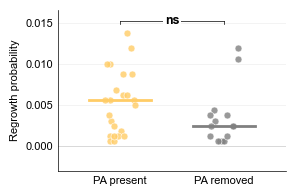

In [12]:
# =============================================================================
# VISUALIZATION — KEEP ORIGINAL STYLE
# =============================================================================
colors = {'PA present': '#ffcc66', 'PA removed': 'grey'}
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
x_positions = {strain: i for i, strain in enumerate(strains_order)}

np.random.seed(42)
for strain in strains_order:
    strain_data = chamber_means[chamber_means['strain'] == strain]['mean_regrowth_fraction'].values
    x_pos = x_positions[strain]
    zeros = strain_data == 0
    non_zeros = strain_data > 0

    if zeros.sum() > 0:
        zero_values = strain_data[zeros]
        zero_y = np.random.uniform(-0.00005, 0.00005, len(zero_values))
        zero_jitter = np.random.uniform(-0.25, 0.25, len(zero_values))
        ax.scatter(np.full(len(zero_values), x_pos) + zero_jitter, zero_y, color=colors[strain], alpha=0.3, s=8, marker='_', linewidths=2, zorder=1)

    if non_zeros.sum() > 0:
        nonzero_values = strain_data[non_zeros]
        nonzero_jitter = np.random.uniform(-0.15, 0.15, len(nonzero_values))
        ax.scatter(np.full(len(nonzero_values), x_pos) + nonzero_jitter, nonzero_values, color=colors[strain], alpha=0.8, s=25, edgecolors='white', linewidth=0.5, zorder=3)

    median_val = np.median(strain_data)
    ax.plot([x_pos - 0.3, x_pos + 0.3], [median_val, median_val], color=colors[strain], linewidth=2, zorder=4)

ax.axhline(y=0, color='lightgray', linestyle='-', linewidth=0.5, zorder=0)

wt_x, hr_x = x_positions['PA present'], x_positions['PA removed']
y_max = chamber_means['mean_regrowth_fraction'].max()
y_pos = y_max * 1.1
ax.plot([wt_x, hr_x], [y_pos, y_pos], color='black', linewidth=0.5)
ax.plot([wt_x, wt_x], [y_pos, y_pos - y_max*0.02], color='black', linewidth=0.5)
ax.plot([hr_x, hr_x], [y_pos, y_pos - y_max*0.02], color='black', linewidth=0.5)

p = pvalues_vs_wt['PA removed']
star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text((wt_x + hr_x)/2, y_pos, star, ha='center', va='center', fontsize=9, color='black', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', pad=1))

ax.set_xlim(-0.6, len(strains_order) - 0.4)
ax.set_xticks(range(len(strains_order)))
ax.set_xticklabels(strains_order, fontsize=8, rotation=0, ha='center')
ax.set_ylabel('Regrowth probability', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(width=0.5, length=2, labelsize=8)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_ylim(-0.003, y_max*1.2)
ax.tick_params(length=0)  # removes the tick marks

plt.tight_layout()
output_pdf = 'S8A_pa_removed_overall_regrowth_probability.pdf'
plt.savefig(output_pdf, dpi=300, bbox_inches='tight')
print(f"✅ Figure saved: {output_pdf}")
plt.show()
